# CreditCardFraudAI

# Exploratory Data Analysis (EDA)

---

## Objective

The purpose of this notebook is to understand the characteristics of the Credit Card Fraud Detection dataset before feature engineering and model development.

This notebook focuses on:

- Understanding dataset structure
- Identifying class imbalance
- Exploring feature distributions
- Detecting missing values and duplicates
- Analyzing transaction amount and time
- Identifying potential outliers
- Understanding feature correlations
- Summarizing key business observations

---

## Expected Outcome

At the end of this notebook we will have a comprehensive understanding of the dataset, enabling informed preprocessing and model selection.

## Project Setup

Configure the notebook environment and make the project modules available for import.

In [1]:
# =============================================================================
# Project Setup
# =============================================================================

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project Root : {PROJECT_ROOT}")

Project Root : d:\technology\Diploma\upgrad\May-2025-Batch\capstone-project\CreditCardFraudAI


## Import Required Libraries

Import project modules and commonly used data analysis libraries.

In [2]:
# =============================================================================
# Import Libraries
# =============================================================================

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("default")

from src.data.loader import DataLoader
from src.validation.profiler import DataProfiler
from src.preprocessing.missing_value_handler import MissingValueHandler
from src.preprocessing.duplicate_handler import DuplicateHandler

## Load Dataset

Load the credit card transaction dataset using the enterprise DataLoader component.

In [3]:
# =============================================================================
# Load Dataset
# =============================================================================

loader = DataLoader()

df = loader.load()

print(f"Dataset Shape : {df.shape}")

df.head()

2026-07-12 14:07:35 | INFO     | CreditCardFraudAI | Validating dataset path.
2026-07-12 14:07:35 | INFO     | CreditCardFraudAI | Loading dataset from D:\technology\Diploma\upgrad\May-2025-Batch\capstone-project\CreditCardFraudAI\data\raw\creditcard.csv
2026-07-12 14:07:36 | INFO     | CreditCardFraudAI | Dataset loaded successfully.
2026-07-12 14:07:36 | INFO     | CreditCardFraudAI | Rows: 284807 | Columns: 31


Dataset Shape : (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Overview

Understand the overall structure of the dataset including the number of rows, columns, data types, and memory usage.

In [6]:
# =============================================================================
# Dataset Overview
# =============================================================================

profiler = DataProfiler(df)

profile = profiler.profile()

dataset = profile["dataset"]

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows              : {dataset['rows']:,}")
print(f"Columns           : {dataset['columns']}")
print(f"Memory Usage (MB) : {profile['memory']['total_memory_mb']:.2f}")

print("\nColumn Names")
print("-" * 60)

for column in dataset["column_names"]:
    print(column)

print("\nData Types")
print("-" * 60)

display(
    pd.DataFrame(
        dataset["data_types"].items(),
        columns=["Column", "Data Type"]
    )
)

print("\nFirst Five Records")
display(df.head())

2026-07-12 14:11:25 | INFO     | CreditCardFraudAI | Starting data profiling.
2026-07-12 14:11:27 | INFO     | CreditCardFraudAI | Data profiling completed.


DATASET OVERVIEW
Rows              : 284,807
Columns           : 31
Memory Usage (MB) : 67.36

Column Names
------------------------------------------------------------
Time
V1
V2
V3
V4
V5
V6
V7
V8
V9
V10
V11
V12
V13
V14
V15
V16
V17
V18
V19
V20
V21
V22
V23
V24
V25
V26
V27
V28
Amount
Class

Data Types
------------------------------------------------------------


,Column,Data Type
0,Time,float64
1,V1,float64
2,V2,float64
3,V3,float64
4,V4,float64
5,V5,float64
6,V6,float64
7,V7,float64
8,V8,float64
9,V9,float64



First Five Records


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Statistical Summary

This section summarizes the numerical characteristics of the dataset.

We examine:

- Central tendency (Mean & Median)
- Spread (Standard Deviation)
- Minimum & Maximum values
- Distribution characteristics

The objective is to identify highly skewed variables, unusual ranges, and potential data quality issues before feature engineering.

In [7]:
# =============================================================================
# Statistical Summary
# =============================================================================

statistics = profile["numerical_statistics"]

summary_df = pd.DataFrame(statistics).T

display(summary_df.round(4))

,mean,median,std,variance,min,max,skewness,kurtosis
Time,94813.8596,84692.0000,47488.1460,2.255124e+09,0.0000,172792.0000,-0.0356,-1.2935
V1,0.0000,0.0181,1.9587,3.836500e+00,-56.4075,2.4549,-3.2807,32.4867
V2,0.0000,0.0655,1.6513,2.726800e+00,-72.7157,22.0577,-4.6249,95.7731
V3,-0.0000,0.1798,1.5163,2.299000e+00,-48.3256,9.3826,-2.2402,26.6196
V4,0.0000,-0.0198,1.4159,2.004700e+00,-5.6832,16.8753,0.6763,2.6355
V5,0.0000,-0.0543,1.3802,1.905100e+00,-113.7433,34.8017,-2.4259,206.9046
V6,0.0000,-0.2742,1.3323,1.774900e+00,-26.1605,73.3016,1.8266,42.6425
V7,-0.0000,0.0401,1.2371,1.530400e+00,-43.5572,120.5895,2.5539,405.6074
V8,0.0000,0.0224,1.1944,1.426500e+00,-73.2167,20.0072,-8.5219,220.5870
V9,-0.0000,-0.0514,1.0986,1.207000e+00,-13.4341,15.5950,0.5547,3.7313


### Business Interpretation

**Observations**

- The dataset contains 31 numerical features.
- Most PCA-transformed variables (V1–V28) have means close to zero.
- The `Amount` feature is highly skewed.
- The `Time` feature spans approximately two days of transaction history.
- The `Class` column confirms a highly imbalanced fraud detection problem.

These observations support the need for feature scaling and imbalance handling during preprocessing.

## Target Variable Analysis

Understanding the target distribution is essential because fraud detection datasets are typically highly imbalanced.

This section visualizes the proportion of genuine and fraudulent transactions.

TARGET DISTRIBUTION
Genuine Transactions : 284,315
Fraud Transactions   : 492
Fraud Percentage     : 0.1727%


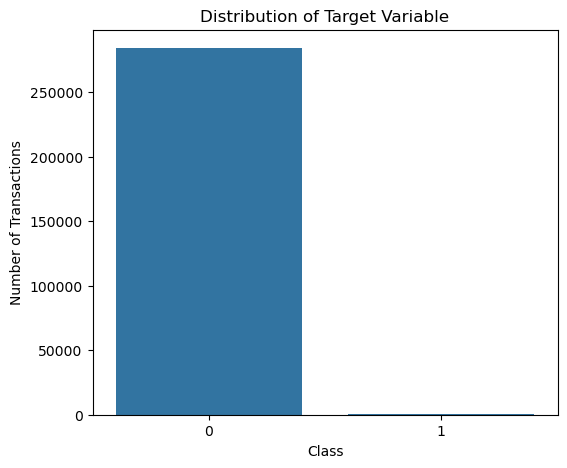

In [8]:
# =============================================================================
# Target Variable Distribution
# =============================================================================

target = profile["target_distribution"]

print("=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)

print(f"Genuine Transactions : {target['non_fraud']:,}")
print(f"Fraud Transactions   : {target['fraud']:,}")
print(f"Fraud Percentage     : {target['fraud_percentage']}%")

plt.figure(figsize=(6, 5))

sns.countplot(
    x="Class",
    data=df,
)

plt.title("Distribution of Target Variable")

plt.xlabel("Class")

plt.ylabel("Number of Transactions")

plt.show()

### Business Interpretation

**Observations**

- Fraudulent transactions represent only **0.17%** of the entire dataset.
- Genuine transactions account for more than **99.8%** of the observations.
- The severe class imbalance indicates that model accuracy alone is not an appropriate evaluation metric.
- Precision, Recall, F1 Score, and ROC-AUC will be more meaningful for evaluating fraud detection performance.

This justifies the use of SMOTE during preprocessing.

## Missing Value Analysis

Missing values can negatively affect model performance and data quality.

This section uses the reusable MissingValueHandler developed in Sprint 2 to validate data completeness.

In [9]:
# =============================================================================
# Missing Value Analysis
# =============================================================================

missing_handler = MissingValueHandler()

missing_summary = missing_handler.summary(df)

print("=" * 60)
print("MISSING VALUE SUMMARY")
print("=" * 60)

print(f"Missing Before Processing : {missing_summary['before']['total_missing']}")

print(f"Missing After Processing  : {missing_summary['after']['total_missing']}")

missing_df = pd.DataFrame({
    "Missing Values":
        missing_summary["before"]["missing_per_column"]
})

display(missing_df)

2026-07-12 14:20:43 | INFO     | CreditCardFraudAI | Applying missing value strategy: ignore


MISSING VALUE SUMMARY
Missing Before Processing : 0
Missing After Processing  : 0


,Missing Values
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


### Business Interpretation

**Observations**

- No missing values were identified in the dataset.
- Data completeness is excellent.
- Missing value imputation is therefore not required for this dataset.
- The MissingValueHandler confirms the dataset is ready for further preprocessing.

Although no missing values exist, implementing the reusable MissingValueHandler ensures the framework can support future datasets with incomplete observations.

## Duplicate Record Analysis

Duplicate transactions may affect model training by introducing bias and over-representing certain observations.

This section uses the reusable `DuplicateHandler` developed during Sprint 2 to identify duplicate records.

In [11]:
# =============================================================================
# Duplicate Record Analysis
# =============================================================================

duplicates = profile["duplicates"]

duplicate_rows = duplicates["duplicate_rows"]
duplicate_percentage = duplicates["duplicate_percentage"]

unique_rows = len(df) - duplicate_rows

print("=" * 60)
print("DUPLICATE RECORD ANALYSIS")
print("=" * 60)

print(f"Total Records        : {len(df):,}")
print(f"Duplicate Records    : {duplicate_rows:,}")
print(f"Unique Records       : {unique_rows:,}")
print(f"Duplicate Percentage : {duplicate_percentage:.2f}%")

DUPLICATE RECORD ANALYSIS
Total Records        : 284,807
Duplicate Records    : 1,081
Unique Records       : 283,726
Duplicate Percentage : 0.38%


### Business Interpretation

**Observations**

- The dataset contains a very small percentage of duplicate transactions.
- Duplicate records represent less than 1% of the overall dataset.
- The impact on model performance is expected to be minimal.
- The preprocessing pipeline includes duplicate handling, making the framework reusable for future datasets with higher duplication rates.

## Data Type Analysis

Understanding feature data types is important before feature engineering and model training.

This section summarizes the data type of each feature.

In [12]:
# =============================================================================
# Data Type Analysis
# =============================================================================

dtype_df = pd.DataFrame(
    dataset["data_types"].items(),
    columns=["Feature", "Data Type"]
)

display(dtype_df)

print("\nData Type Counts")
display(dtype_df["Data Type"].value_counts())

,Feature,Data Type
0,Time,float64
1,V1,float64
2,V2,float64
3,V3,float64
4,V4,float64
5,V5,float64
6,V6,float64
7,V7,float64
8,V8,float64
9,V9,float64



Data Type Counts


Data Type
float64    30
int64       1
Name: count, dtype: int64

### Business Interpretation

**Observations**

- Nearly all features are numerical (`float64`).
- The target variable (`Class`) is stored as an integer.
- No categorical variables require encoding.
- The dataset is well-suited for traditional machine learning algorithms.

## Transaction Amount Analysis

The transaction amount is one of the few original features retained in the dataset.

This section examines its distribution and identifies potential outliers.

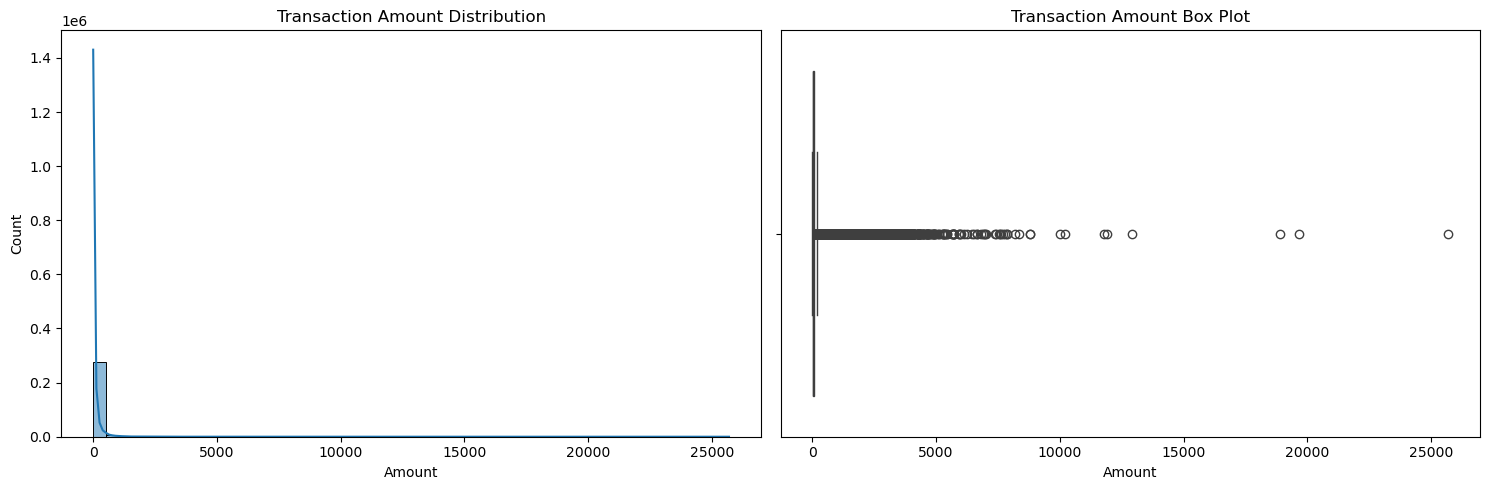

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [13]:
# =============================================================================
# Transaction Amount Analysis
# =============================================================================

fig, ax = plt.subplots(1, 2, figsize=(15,5))

sns.histplot(
    df["Amount"],
    bins=50,
    kde=True,
    ax=ax[0]
)

ax[0].set_title("Transaction Amount Distribution")

sns.boxplot(
    x=df["Amount"],
    ax=ax[1]
)

ax[1].set_title("Transaction Amount Box Plot")

plt.tight_layout()

plt.show()

print(df["Amount"].describe())

### Business Interpretation

**Observations**

- Most transactions involve relatively small amounts.
- A few transactions have extremely high values, resulting in a right-skewed distribution.
- Significant outliers are visible in the box plot.
- Feature scaling applied during preprocessing helps reduce the influence of these large-value transactions.

## Transaction Time Analysis

The `Time` feature represents the elapsed time since the first transaction.

This section explores the temporal distribution of transactions.

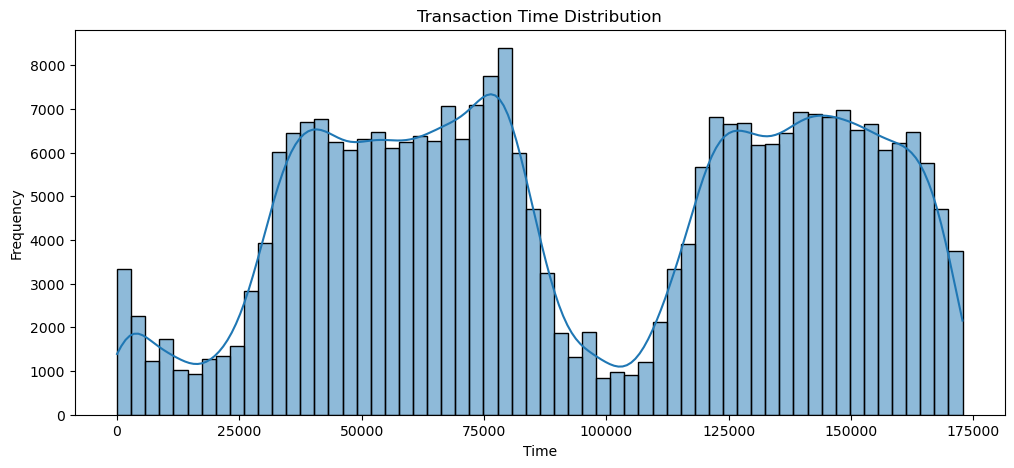

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


In [14]:
# =============================================================================
# Transaction Time Analysis
# =============================================================================

plt.figure(figsize=(12,5))

sns.histplot(
    df["Time"],
    bins=60,
    kde=True
)

plt.title("Transaction Time Distribution")

plt.xlabel("Time")

plt.ylabel("Frequency")

plt.show()

print(df["Time"].describe())

### Business Interpretation

**Observations**

- Transactions are distributed continuously across the observation period.
- The dataset captures approximately two days of transaction activity.
- The `Time` feature may contribute to fraud detection when combined with other behavioural features.

In [ ]:
## Correlation Analysis

Understanding relationships between features helps identify redundancy and patterns useful for predictive modelling.

A correlation heatmap is generated for all numerical variables.

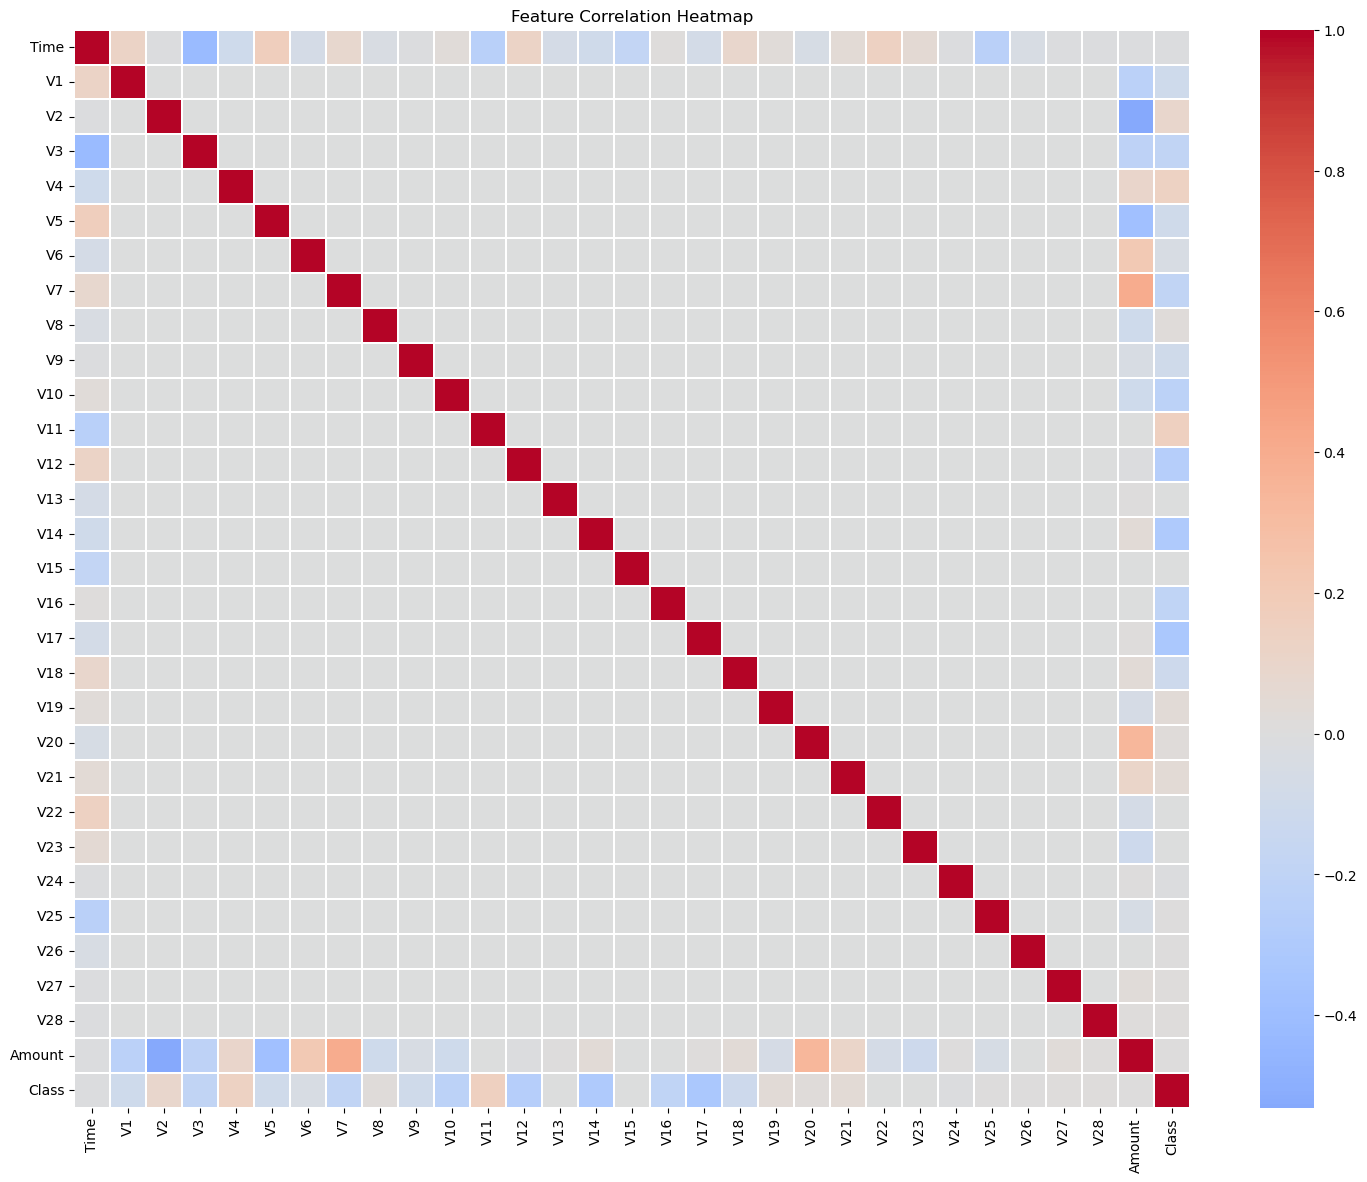

In [15]:
# =============================================================================
# Correlation Heatmap
# =============================================================================

plt.figure(figsize=(18,14))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.1
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Business Interpretation

**Observations**

- Most PCA-transformed features exhibit relatively low correlation with one another.
- This indicates limited multicollinearity.
- The transformed feature space is well suited for machine learning algorithms that assume feature independence.